In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [2]:
best_model = joblib.load("../models/best_model.pkl")

print("Best model loaded successfully!")
print(best_model)

Best model loaded successfully!
RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)


In [3]:
df = pd.read_csv("../data/traffic_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (254, 10)


In [4]:
features = [
    "date",
    "timestamp",
    "direction",
    "day_night",
    "weather",
    "start_frame",
    "number_of_frames"
]

X = df[features].copy()
y = df["traffic_class"]

print("Features and target selected successfully!")

Features and target selected successfully!


In [5]:
X = pd.get_dummies(
    X,
    columns=["direction", "day_night", "weather"],
    drop_first=False
)

print("Categorical features encoded successfully!")
print("Number of features:", X.shape[1])

Categorical features encoded successfully!
Number of features: 9


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 203
Testing samples: 51


In [7]:
best_pred = best_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [8]:
accuracy = accuracy_score(y_test, best_pred)
precision = precision_score(y_test, best_pred, average="weighted")
recall = recall_score(y_test, best_pred, average="weighted")
f1 = f1_score(y_test, best_pred, average="weighted")

print("MODEL EVALUATION")
print("=" * 40)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

MODEL EVALUATION
Accuracy : 0.8824
Precision: 0.8917
Recall   : 0.8824
F1-Score : 0.8852


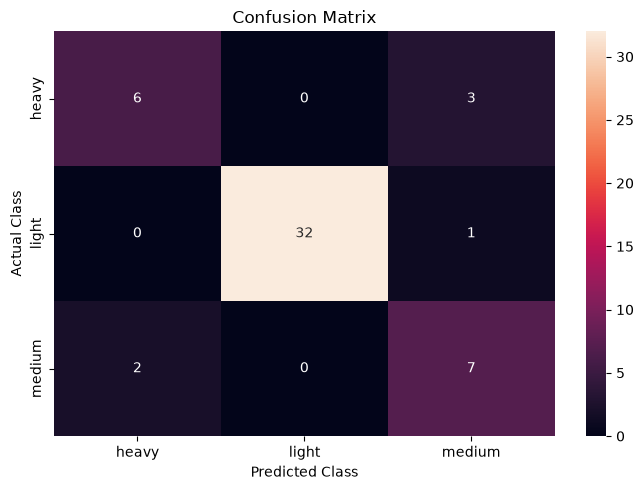

In [9]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print("Classification Report:")
print(classification_report(y_test, best_pred))

Classification Report:
              precision    recall  f1-score   support

       heavy       0.75      0.67      0.71         9
       light       1.00      0.97      0.98        33
      medium       0.64      0.78      0.70         9

    accuracy                           0.88        51
   macro avg       0.80      0.80      0.80        51
weighted avg       0.89      0.88      0.89        51



In [11]:
y_test_binary = label_binarize(
    y_test,
    classes=best_model.classes_
)

y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test_binary,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9695


## Final observation
The saved best Random Forest model was loaded successfully.
The model was used to predict traffic classes for the test data.
Accuracy, Precision, Recall, and F1-score were calculated.
A confusion matrix and classification report were generated to evaluate predictions.
ROC-AUC was also calculated to measure the classification performance.